# Image Segmentation and Edge Detection - Student Tasks

Using real image: mesi.jpg

Image shape: (360, 640)


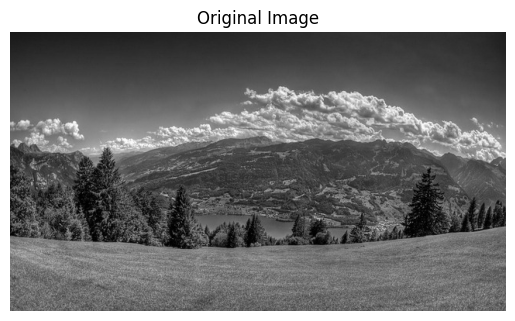

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.filters import threshold_otsu
from skimage.feature import canny

# Load the image
image = np.array(Image.open("nature.jpg").convert("L"))
print(f"Image shape: {image.shape}")

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

## Task 1: Try Different Threshold Values

Test thresholds: 60, 100, 140, 180

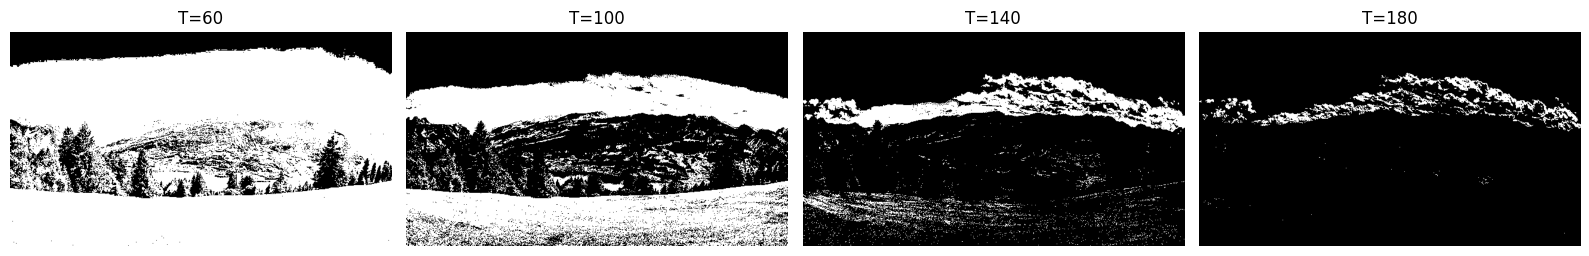

Lower T -> more white pixels
Higher T -> fewer white pixels (more black )


In [2]:
thresholds = [60, 100, 140, 180]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, T in enumerate(thresholds):
    mask = (image >= T).astype(np.uint8)
    axes[i].imshow(mask, cmap='gray')
    axes[i].set_title(f'T={T}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

print("Lower T -> more white pixels")
print("Higher T -> fewer white pixels (more black )")

## Task 2: Build Your Own Segmentation Function

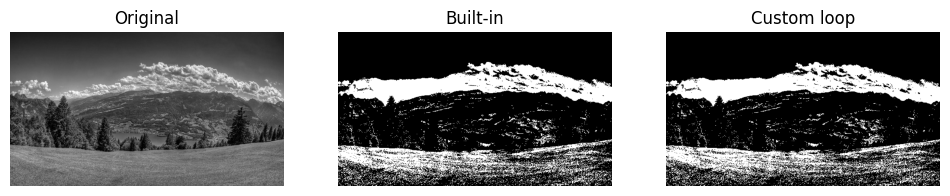

Results match: True


In [3]:
def my_threshold(image, T):
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            result[i, j] = 1 if image[i, j] >= T else 0
    return result.astype(np.uint8)

T = 120
mask1 = (image >= T).astype(np.uint8)
mask2 = my_threshold(image, T)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(mask1, cmap='gray')
axes[1].set_title('Built-in')
axes[2].imshow(mask2, cmap='gray')
axes[2].set_title('Custom loop')
for ax in axes: ax.axis('off')
plt.show()

print(f"Results match: {np.array_equal(mask1, mask2)}")

## Task 3: Noise Challenge

Add noise and see effect on segmentation

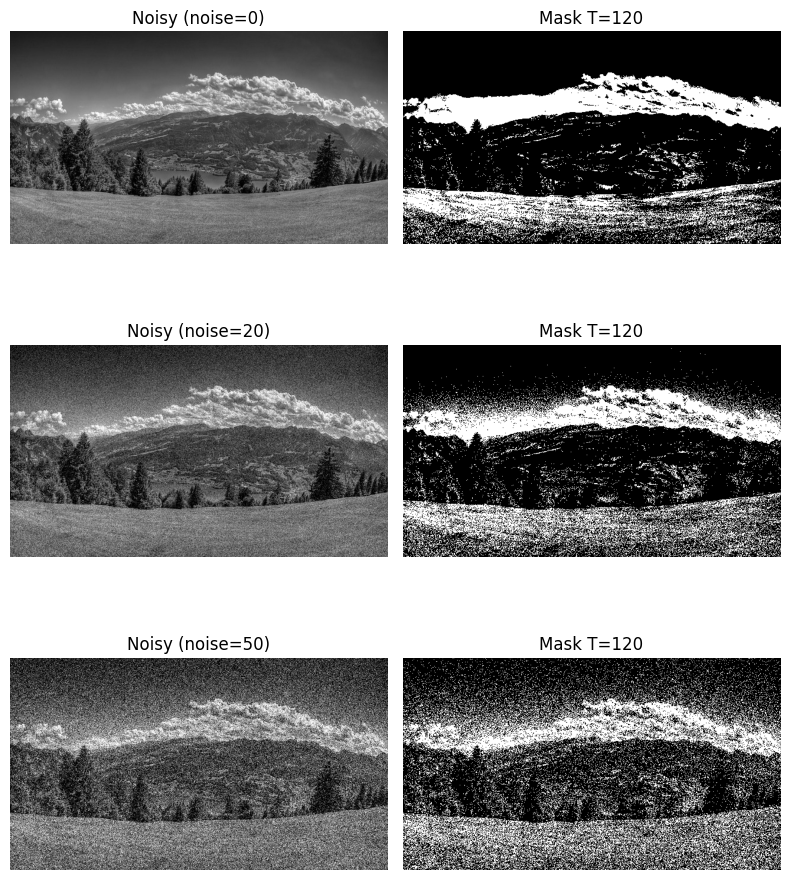

More noise -> messier mask
Solution: apply gaussian_filter before thresholding


In [4]:
from scipy.ndimage import gaussian_filter

noise_levels = [0, 20, 50]
T = 120

fig, axes = plt.subplots(3, 2, figsize=(8, 10))

for i, noise in enumerate(noise_levels):
    noisy = np.clip(image + np.random.normal(0, noise, image.shape), 0, 255).astype(np.uint8)
    mask = (noisy >= T).astype(np.uint8)
    
    axes[i, 0].imshow(noisy, cmap='gray')
    axes[i, 0].set_title(f'Noisy (noise={noise})')
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'Mask T={T}')
    
for ax in axes.flat: ax.axis('off')
plt.tight_layout()
plt.show()

print("More noise -> messier mask")
print("Solution: apply gaussian_filter before thresholding")

## Challenge 1: Automatic Threshold (Otsu)

Otsu's threshold: 95


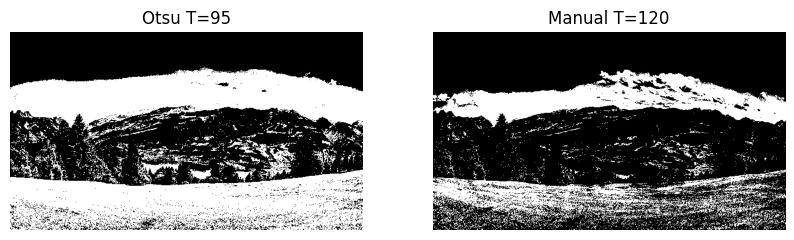

In [5]:
T_otsu = threshold_otsu(image)
print(f"Otsu's threshold: {T_otsu}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow((image >= T_otsu).astype(np.uint8), cmap='gray')
axes[0].set_title(f"Otsu T={T_otsu}")
axes[1].imshow((image >= 120).astype(np.uint8), cmap='gray')
axes[1].set_title("Manual T=120")
for ax in axes: ax.axis('off')
plt.show()

## Challenge 2: Count White Pixels

In [6]:
T = 120
mask = (image >= T).astype(np.uint8)

white_pixels = np.sum(mask == 1)
total_pixels = mask.size
percentage = white_pixels / total_pixels * 100

print(f"White pixels: {white_pixels}")
print(f"Total pixels: {total_pixels}")
print(f"Percentage: {percentage:.1f}%")

White pixels: 57859
Total pixels: 230400
Percentage: 25.1%


## Challenge 3: Sobel vs Canny Edge Detection

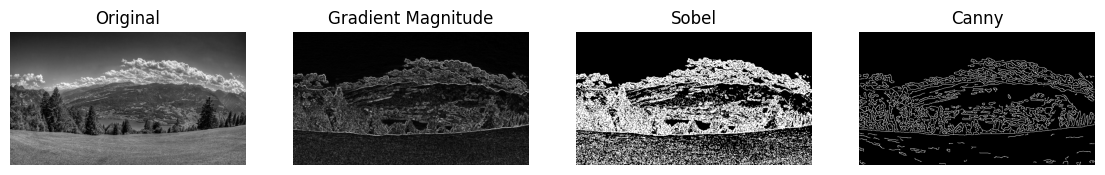

Canny gives cleaner, thinner edges
Sobel is more sensitive to noise


In [7]:
# Sobel (manual implementation)
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

from scipy.ndimage import convolve
Gx = convolve(image.astype(np.float32), sobel_x)
Gy = convolve(image.astype(np.float32), sobel_y)
grad_mag = np.sqrt(Gx**2 + Gy**2)
sobel_edges = (grad_mag >= 80).astype(np.uint8)

# Canny
canny_edges = canny(image, sigma=1.5).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(grad_mag, cmap='gray')
axes[1].set_title('Gradient Magnitude')
axes[2].imshow(sobel_edges, cmap='gray')
axes[2].set_title('Sobel')
axes[3].imshow(canny_edges, cmap='gray')
axes[3].set_title('Canny')
for ax in axes: ax.axis('off')
plt.show()

print("Canny gives cleaner, thinner edges")
print("Sobel is more sensitive to noise")

## Mini Project: Complete Pipeline

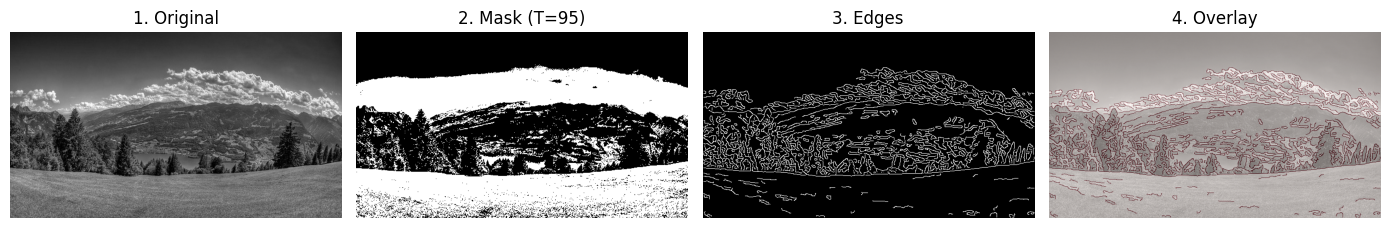

Threshold: 95
Edge pixels: 19445


In [8]:
# Pipeline
T = threshold_otsu(image)
mask = (image >= T).astype(np.uint8)
edges = canny(image, sigma=1.5).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('1. Original')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'2. Mask (T={T})')
axes[2].imshow(edges, cmap='gray')
axes[2].set_title('3. Edges')
axes[3].imshow(image, cmap='gray')
axes[3].imshow(edges, cmap='Reds', alpha=0.5)
axes[3].set_title('4. Overlay')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Threshold: {T}")
print(f"Edge pixels: {np.sum(edges == 1)}")